<a href="https://colab.research.google.com/github/WillowStevens/pod-project/blob/main/Data_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NNE Gas Dashboard Data Cleaning**

This notebook is designed to process the data set provided for our NNE Gas Dashbaord

In [4]:
# Hackathon Data Cleaning Template
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the Dataset
# Update the file path once the dataset is available
file_path = "/content/dummy_energy_data.csv"  # Replace with your actual file path
try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Please provide the correct file path.")

# Preview the first few rows
print(data.head())

# Step 3: Initial Dataset Overview
# Display basic information about the dataset
print("\nDataset Information:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Generate summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Step 4: Data Cleaning
# Handle missing values
# Apply the mean only to numeric columns
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())

# Drop duplicates
data.drop_duplicates(inplace=True)

# Rename columns for clarity
data.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)

# Convert data types (e.g., datetime)
if 'timestamp' in data.columns:
    data['timestamp'] = pd.to_datetime(data['timestamp'])

# Validate cleaning
print("\nPost-cleaning validation:")
print("Missing values after cleaning:", data.isnull().sum())
print("Duplicate rows:", data.duplicated().sum())

# Step 5: Aggregations for Qlik Import / Forecasting Model

# Ensure 'timestamp' is a datetime column
if 'timestamp' in data.columns:
    data['timestamp'] = pd.to_datetime(data['timestamp'])  # Convert to datetime if not already
    data.set_index('timestamp', inplace=True)

    # Perform aggregations
    hourly_data = data.resample('H').mean()  # Hourly aggregation
    daily_data = data.resample('D').mean()   # Daily aggregation
    weekly_data = data.resample('W').mean()  # Weekly aggregation

    # Reset index for exporting
    hourly_data.reset_index(inplace=True)
    daily_data.reset_index(inplace=True)
    weekly_data.reset_index(inplace=True)

    # Save the aggregated datasets
    hourly_data.to_csv("hourly_data.csv", index=False)
    daily_data.to_csv("daily_data.csv", index=False)
    weekly_data.to_csv("weekly_data.csv", index=False)

    # Print previews for validation
    print("\nPreview of hourly aggregated data:")
    print(hourly_data.head())
    print("\nPreview of daily aggregated data:")
    print(daily_data.head())
    print("\nPreview of weekly aggregated data:")
    print(weekly_data.head())

# Step 6: Save the Cleaned Data
# Save cleaned raw dataset
output_file_path = "cleaned_data.csv"
data.to_csv(output_file_path, index=False)
print(f"Cleaned raw data saved to {output_file_path}")

# Save daily aggregated data
daily_output_path = "daily_aggregated_data.csv"
daily_data.to_csv(daily_output_path, index=False)
print(f"Daily aggregated data saved to {daily_output_path}")




Dataset loaded successfully.
             timestamp  household_usage  kitchen  heating  laundry
0  2023-01-01 00:00:00             2.17     0.56     0.50     0.43
1  2023-01-01 01:00:00             2.79     1.37     2.00     0.74
2  2023-01-01 02:00:00             2.44     0.64     1.65     0.43
3  2023-01-01 03:00:00             3.77     0.25     0.80     0.82
4  2023-01-01 04:00:00             0.84     0.83     0.84     0.58

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        4320 non-null   object 
 1   household_usage  4320 non-null   float64
 2   kitchen          4320 non-null   float64
 3   heating          4320 non-null   float64
 4   laundry          4320 non-null   float64
dtypes: float64(4), object(1)
memory usage: 168.9+ KB
None

Missing Values:
timestamp          0
household_usage    0
k

<ipython-input-4-63eecb052b33>:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = data.resample('H').mean()  # Hourly aggregation


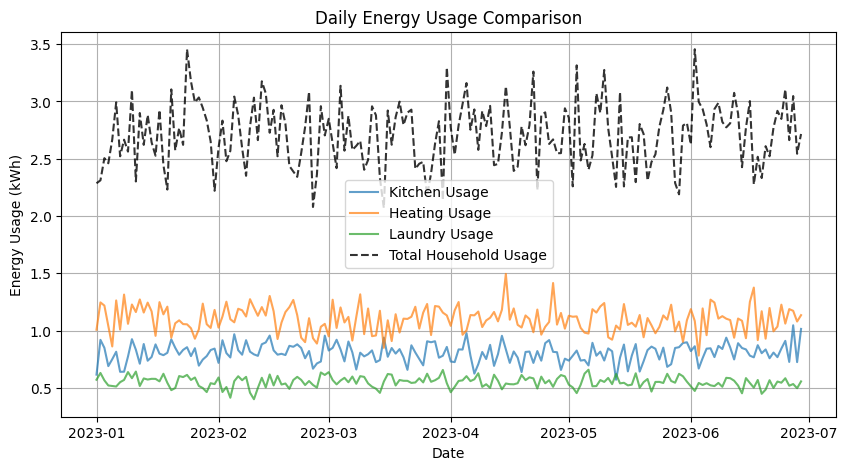

In [5]:
# Line chart for daily data
plt.figure(figsize=(10, 5))
plt.plot(daily_data['timestamp'], daily_data['kitchen'], label='Kitchen Usage', alpha=0.7)
plt.plot(daily_data['timestamp'], daily_data['heating'], label='Heating Usage', alpha=0.7)
plt.plot(daily_data['timestamp'], daily_data['laundry'], label='Laundry Usage', alpha=0.7)
plt.plot(daily_data['timestamp'], daily_data['household_usage'], label='Total Household Usage', linestyle='--', color='black', alpha=0.8)
plt.title('Daily Energy Usage Comparison')
plt.xlabel('Date')
plt.ylabel('Energy Usage (kWh)')
plt.legend()
plt.grid()
plt.show()


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'timestamp' is set as a DatetimeIndex
daily_data['timestamp'] = pd.to_datetime(daily_data['timestamp'])  # Convert to datetime
daily_data.set_index('timestamp', inplace=True)  # Set as index if not already

# Forecast settings
forecast_periods = 30
metrics = ['kitchen', 'heating', 'laundry', 'household_usage']

# Initialize a dictionary to store forecasted values
forecast_results = {}

# Fit and forecast for each metric
for metric in metrics:
    model = ExponentialSmoothing(
        daily_data[metric],  # Use the current metric
        trend='add',  # Additive trend
        seasonal='add',  # Additive seasonality
        seasonal_periods=7  # Weekly seasonality
    ).fit()

    # Forecast for the current metric
    forecast = model.forecast(steps=forecast_periods)
    forecast_results[metric] = forecast

# Generate forecast dates
forecast_start_date = daily_data.index[-1] + pd.Timedelta(days=1)
forecast_dates = pd.date_range(start=forecast_start_date, periods=forecast_periods, freq='D')

# Create a DataFrame for forecasted values
forecast_data = pd.DataFrame({'timestamp': forecast_dates})
for metric in metrics:
    forecast_data[metric] = forecast_results[metric].values

# Combine historical and forecasted data
historical_data = daily_data.reset_index()
full_data = pd.concat([historical_data, forecast_data])

# Preview the combined data
print(full_data.head())


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


   timestamp  household_usage   kitchen   heating   laundry
0 2023-01-01         2.285833  0.616667  1.008333  0.572083
1 2023-01-02         2.311667  0.920000  1.246667  0.631250
2 2023-01-03         2.505000  0.850417  1.219167  0.566667
3 2023-01-04         2.460417  0.690833  1.039167  0.522083
4 2023-01-05         2.667083  0.751250  0.862500  0.517083


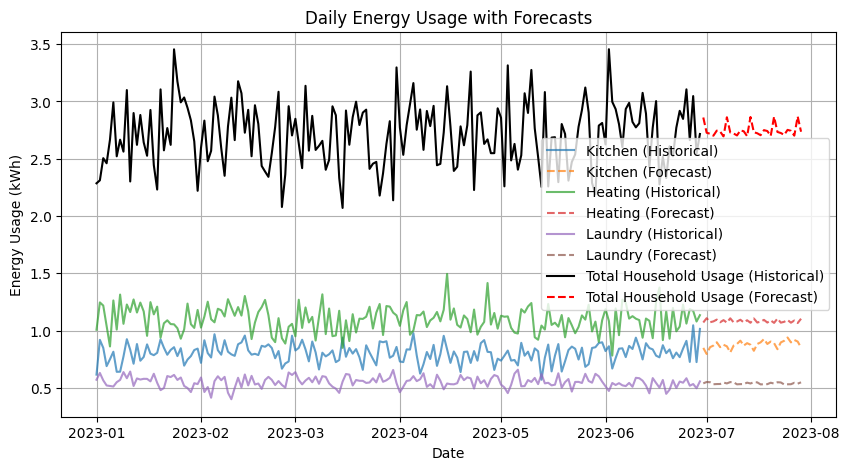

In [9]:
# Plot historical and forecasted values for all metrics
plt.figure(figsize=(10, 5))
for metric in metrics[:-1]:  # Exclude total for individual lines
    plt.plot(historical_data['timestamp'], historical_data[metric], label=f'{metric.capitalize()} (Historical)', alpha=0.7)
    plt.plot(forecast_data['timestamp'], forecast_data[metric], linestyle='--', label=f'{metric.capitalize()} (Forecast)', alpha=0.7)
# Add total usage (household_usage)
plt.plot(historical_data['timestamp'], historical_data['household_usage'], linestyle='-', color='black', label='Total Household Usage (Historical)', linewidth=1.5)
plt.plot(forecast_data['timestamp'], forecast_data['household_usage'], linestyle='--', color='red', label='Total Household Usage (Forecast)', linewidth=1.5)

# Add titles and labels
plt.title('Daily Energy Usage with Forecasts')
plt.xlabel('Date')
plt.ylabel('Energy Usage (kWh)')
plt.legend()
plt.grid()
plt.show()


       household_usage     kitchen     heating     laundry
count       180.000000  180.000000  180.000000  180.000000
mean          2.710493    0.805257    1.100854    0.552516
std           0.282550    0.081601    0.115501    0.047641
min           2.070833    0.572083    0.782917    0.402083
25%           2.516771    0.752500    1.024167    0.521875
50%           2.721458    0.811458    1.104792    0.553125
75%           2.918646    0.852604    1.182917    0.585625
max           3.455417    1.047083    1.495417    0.659583


In [13]:
full_data.to_csv("full_energy_data.csv", index=False)
print("Full dataset saved to 'full_energy_data.csv'")

Full dataset saved to 'full_energy_data.csv'
